In [62]:
import numpy as np
from scipy.optimize import curve_fit, least_squares, leastsq
from scipy.special import gamma
from scipy import constants
from matplotlib import pyplot as plt
import uncertainties
from uncertainties import umath
%matplotlib inline

In [33]:
π = np.pi
def mmGp(ω, k, η):
    '''Elastic modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ**2 * ω**2
    )/(
        1 + τ**2 * ω**2
    )
def mmGpp(ω, k, η):
    '''Viscous modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ * ω
    )/(
        1 + τ**2 * ω**2
    )
def mmtandelta(ω, k, η):
    '''Loss tangent of the Maxwell Model'''
    τ = η/k
    return 1/(τ * ω)

def mmJ(t, k, η):
    '''Creep compliance of the Maxwell Model'''
    return 1/k + t/η

In [35]:
def fit_mm(omegas, Gp, Gpp, k0=1, η0=1):
    """Fit simultaneously G' and G'' to the Maxwell Model"""
    assert len(omegas) == len(Gp)
    assert len(omegas) == len(Gpp)
    return curve_fit(
        f=lambda ω, k,η: np.concatenate([np.log(mmGp(ω, k, η)), np.log(mmGpp(ω, k, η))]), 
        xdata=omegas, 
        ydata=np.concatenate([np.log(Gp), np.log(Gpp)]),
        p0=[k0, η0], 
        bounds=([0,0], [np.inf, np.inf])
    )

# Fractional Maxwell Model

In [2]:
π = np.pi
def fmmGp(ω, V, G, α, β):
    '''Elastic modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.cos(π*α/2) + Vo**2 * Go * np.cos(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmGpp(ω, V, G, α, β):
    '''Viscous modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.sin(π*α/2) + Vo**2 * Go * np.sin(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmtandelta(ω, V, G, α, β):
    '''Loss tangent of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go * np.sin(π*α/2) + Vo * np.sin(π*β/2)
    )/(
        Go * np.cos(π*α/2) + Vo * np.cos(π*β/2)
    )

def fmmJ(t, V, G, α, β):
    '''Creep compliance of the Fractional Maxwell Model'''
    return t**α/(V*gamma(1+α)) + t**β/(G*gamma(1+β))

def fmmTau(V, G, α, β):
    '''Characteristic time of the Fractional Maxwell Model'''
    return (V/G * (np.cos(π*β/2) - np.sin(π*β/2)) / (np.sin(π*α/2) - np.cos(π*α/2)))**(1/(α-β))

def fmmVGratio(τ, α, β):
    '''Ratio between quasi-properties V / G, given characteristic time tau and exponents alpha and beta'''
    return (np.sin(π*α/2) - np.cos(π*α/2)) / (np.cos(π*β/2) - np.sin(π*β/2)) * tau**(α-β)

def fmmMSD(t, Dα, τ, α, β):
    '''Mean square displacement in the Fractional Maxwell Model'''
    return 2*Dα * (τ**(α-β) * t**β/gamma(1+β) + t**α/gamma(1+α))

In [41]:
def fit_fmm(omegas, Gp, Gpp, V0=1, G0=1, α0=1, β0=0):
    """Fit simultaneously G' and G'' to the Fractional Maxwell Model"""
    assert len(omegas) == len(Gp)
    assert len(omegas) == len(Gpp)
    return curve_fit(
        f=lambda ω, V, G, α, β: np.concatenate([np.log(fmmGp(ω, V, G, α, β)), np.log(fmmGpp(ω, V, G, α, β))]), 
        xdata=omegas, 
        ydata=np.concatenate([np.log(Gp), np.log(Gpp)]),
        p0=[V0, G0, α0, β0], 
        #sigma=res_phi/phi[m:M2]
        bounds=([0,0,0,0], [np.inf, np.inf, 1, 1])
    )

def fit_fmm_torque(omegas, Gp, Gpp, torque, V0=1, G0=1, α0=1, β0=0):
    """Fit simultaneously G' and G'' to the Fractional Maxwell Model"""
    assert len(omegas) == len(Gp)
    assert len(omegas) == len(Gpp)
    return curve_fit(
        f=lambda ω, V, G, α, β: np.concatenate([np.log(fmmGp(ω, V, G, α, β)), np.log(fmmGpp(ω, V, G, α, β))]), 
        xdata=omegas, 
        ydata=np.concatenate([np.log(Gp), np.log(Gpp)]),
        p0=[V0, G0, α0, β0], 
        sigma=np.concatenate([1/torque]*2),
        bounds=([0,0,0,0], [np.inf, np.inf, 1, 1])
    )

def fit_fmm_alpha1(omegas, Gp, Gpp, V0=1, G0=1, β0=0):
    """Fit simultaneously G' and G'' to the Fractional Maxwell Model with alpha exponent set to 1."""
    assert len(omegas) == len(Gp)
    assert len(omegas) == len(Gpp)
    α = 1
    p = curve_fit(
        f=lambda ω, V, G, β: np.concatenate([np.log(fmmGp(ω, V, G, α, β)), np.log(fmmGpp(ω, V, G, α, β))]), 
        xdata=omegas, 
        ydata=np.concatenate([np.log(Gp), np.log(Gpp)]),
        p0=[V0, G0, β0], 
        #sigma=res_phi/phi[m:M2]
    )[0]
    return np.array([p[0], p[1], 1, p[2]])

In [36]:
omega, Gp, Gpp, tandelta, torque = np.loadtxt('Y6_FS_T25_after1h_70C_1.txt', skiprows=11, usecols=[1,2,3,4,7], unpack=True)
relerr = 1e-3/torque

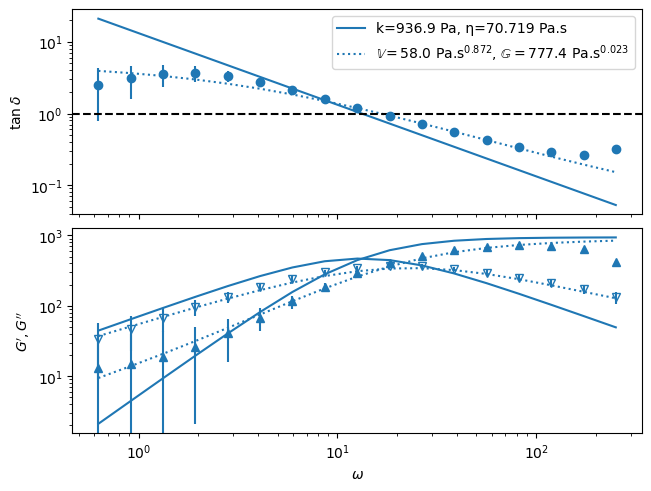

In [73]:
fig, axs = plt.subplots(2,1, sharex=True, layout="constrained")
line = axs[0].errorbar(omega, tandelta, tandelta*relerr, fmt='o')[0]
axs[1].errorbar(omega, Gp, np.sqrt(Gp**2+Gpp**2)*relerr, fmt='^', label=fr'$G^\prime$', color=line.get_color())
axs[1].errorbar(omega, Gpp, np.sqrt(Gp**2+Gpp**2)*relerr, fmt='v', label=fr'$G^{{\prime\prime}}$', color=line.get_color(), mfc='none')

k, η = fit_mm(omega, Gp, Gpp)[0]
axs[0].plot(omega, mmtandelta(omega, k, η), '-', color=line.get_color(), label=f'k={k:0.1f} Pa, η={η:.03f} Pa.s')
axs[1].plot(omega, mmGp(omega, k, η), '-', color=line.get_color())
axs[1].plot(omega, mmGpp(omega, k, η), '-', color=line.get_color())

V, G, α, β = fit_fmm(omega, Gp, Gpp)[0]
axs[0].plot(
    omega, fmmtandelta(omega, V, G, α, β), ':', color=line.get_color(), 
    label=fr'$\mathbb{{V}}={V:.01f}$ Pa.s$^{{{α:.03f}}}$, $\mathbb{{G}}={G:0.1f}$ Pa.s$^{{{β:.03f}}}$'
)
axs[1].plot(omega, fmmGp(omega, V, G, α, β), ':', color=line.get_color())
axs[1].plot(omega, fmmGpp(omega, V, G, α, β), ':', color=line.get_color())

plt.xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'$\omega$')
axs[0].set_ylabel(r'$\tan\delta$')
axs[1].set_ylabel(r'$G^\prime, G^{\prime\prime}$')
axs[0].legend()
axs[0].axhline(1,ls='--', color='k')
for ext in ['pdf', 'png']:
    plt.savefig(f'2024_07_09_Y6_after2h_at70C_FS_25C.{ext}')

In [65]:
η/k, fmmTau(V, G, α, β)

(0.07548622955792417, 0.06210834244191808)

In [63]:
G/(constants.R * constants.convert_temperature(25, 'C', 'K'))

0.29032078439496717

$\mathbb{V}=38.1$ Pa.s$^{0.922}$, $\mathbb{G}=648.2$ Pa.s$^{0.041}$, τ=43.4 ms
$\mathbb{V}=42.0$ Pa.s$^{0.900}$, $\mathbb{G}=605.6$ Pa.s$^{0.048}$, τ=49.1 ms
$\mathbb{V}=43.9$ Pa.s$^{0.909}$, $\mathbb{G}=593.9$ Pa.s$^{0.057}$, τ=51.0 ms
$\mathbb{V}=45.3$ Pa.s$^{0.898}$, $\mathbb{G}=786.9$ Pa.s$^{0.020}$, τ=46.2 ms
$\mathbb{V}=46.5$ Pa.s$^{0.896}$, $\mathbb{G}=884.2$ Pa.s$^{0.006}$, τ=44.9 ms
$\mathbb{V}=48.2$ Pa.s$^{0.912}$, $\mathbb{G}=688.9$ Pa.s$^{0.039}$, τ=53.1 ms
$\mathbb{V}=50.0$ Pa.s$^{0.911}$, $\mathbb{G}=720.3$ Pa.s$^{0.035}$, τ=53.6 ms
$\mathbb{V}=51.6$ Pa.s$^{0.905}$, $\mathbb{G}=833.3$ Pa.s$^{0.020}$, τ=50.6 ms
$\mathbb{V}=53.4$ Pa.s$^{0.915}$, $\mathbb{G}=673.0$ Pa.s$^{0.045}$, τ=59.5 ms
$\mathbb{V}=54.8$ Pa.s$^{0.921}$, $\mathbb{G}=634.0$ Pa.s$^{0.052}$, τ=63.6 ms
$\mathbb{V}=57.4$ Pa.s$^{0.896}$, $\mathbb{G}=719.7$ Pa.s$^{0.035}$, τ=62.1 ms


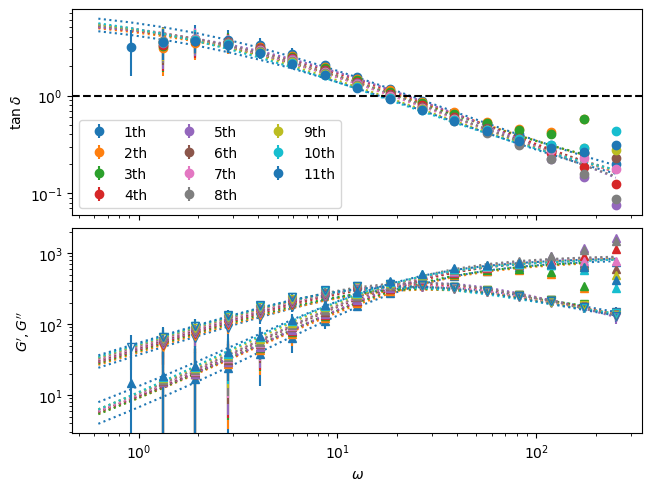

In [70]:
fig, axs = plt.subplots(2,1, sharex=True, layout="constrained")
taus = []
for i in range(1,12):
    omega, Gp, Gpp, tandelta, torque = np.loadtxt(f'Y6_FS_T30_after1h_70C_{i}.txt', skiprows=11, usecols=[1,2,3,4,7], unpack=True)
    relerr = 1e-3/torque
    good = relerr<0.5
    line = axs[0].errorbar(omega[good], tandelta[good], (tandelta*relerr)[good], fmt='o', label=f'{i}th')[0]
    axs[1].errorbar(omega[good], Gp[good], (np.sqrt(Gp**2+Gpp**2)*relerr)[good], fmt='^', label=fr'$G^\prime$', color=line.get_color())
    axs[1].errorbar(omega[good], Gpp[good], (np.sqrt(Gp**2+Gpp**2)*relerr)[good], fmt='v', label=fr'$G^{{\prime\prime}}$', color=line.get_color(), mfc='none')
    V, G, α, β = fit_fmm(omega[good], Gp[good], Gpp[good])[0]
    axs[0].plot(omega, fmmtandelta(omega, V, G, α, β), ':', color=line.get_color())
    axs[1].plot(
        omega, fmmGp(omega, V, G, α, β), ':', color=line.get_color(), 
        label=fr'$\mathbb{{V}}={V:.01f}$ Pa.s$^{{{α:.03f}}}$, $\mathbb{{G}}={G:0.1f}$ Pa.s$^{{{β:.03f}}}$'
    )
    taus.append(fmmTau(V, G, α, β))
    print(fr'$\mathbb{{V}}={V:.01f}$ Pa.s$^{{{α:.03f}}}$, $\mathbb{{G}}={G:0.1f}$ Pa.s$^{{{β:.03f}}}$, τ={fmmTau(V, G, α, β)*1000:.01f} ms')
    axs[1].plot(omega, fmmGpp(omega, V, G, α, β), ':', color=line.get_color())
plt.xscale('log')
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'$\omega$')
axs[0].set_ylabel(r'$\tan\delta$')
axs[1].set_ylabel(r'$G^\prime, G^{\prime\prime}$')
axs[0].legend(ncols=3)
#axs[1].legend(ncols=3)
axs[0].axhline(1,ls='--', color='k')
taus = np.array(taus)

(52.464517666387714, 6.495931121872993)

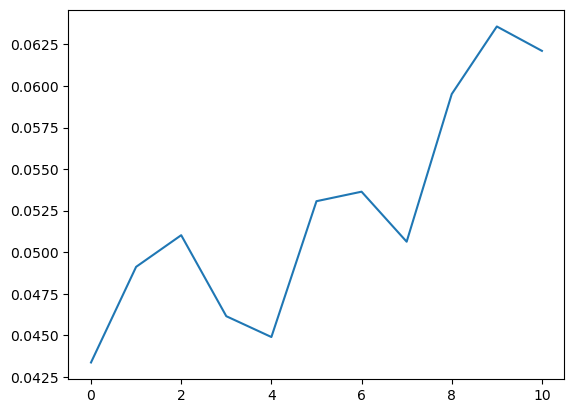

In [72]:
plt.plot(taus)
taus.mean()*1e3, taus.std()*1e3